## Correction playground

This serves as an example on how an analyst can modify/add corrections according to their analysis. It builds on the SysVar 101 example so it is consistent and easy to follow. We will demonstrate here PID, BF and custom corrections as described in the corrections chapter since these are the ones that are very analysis specific and requires the analyst to describe them accordingly.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sample_size = 2000
theta =  5.5
momentum_scaler =MinMaxScaler((0.05, 0.4))
momentum_scaler.fit(np.random.gamma(theta, 1.0, sample_size).reshape(-1, 1))
toy_df = pd.DataFrame(
    {
        "channel": np.random.randint(0, 2, sample_size), # Assume 4 reco channels,
        "template": np.random.randint(1, 3, sample_size), # Assume 2 templates, 1 = signal and 2 = BKG
        "slow_pi_p": momentum_scaler.transform(np.random.gamma(theta, 1.0, sample_size).reshape(-1, 1)).flatten(),
    }
)

toy_df["slow_pi_mcPDG"] =  np.random.choice([-211, 211], sample_size)
toy_df["slow_pi_PDG"] =  np.random.choice([-211, 211], sample_size)

toy_df.loc[toy_df.template == 1, "fit_variable1"] = np.random.exponential(0.2, len(toy_df[toy_df.template == 1]))
toy_df.loc[toy_df.template == 1, "fit_variable2"] = np.random.normal(2.5, 0.3, len(toy_df[toy_df.template == 1]))
toy_df.loc[toy_df.template == 1, "other_weight"] = np.random.normal(0.3, 0.04, len(toy_df[toy_df.template == 1]))
toy_df.loc[toy_df.template == 2, "fit_variable1"] = np.random.power(1.5, len(toy_df[toy_df.template == 2]))
toy_df.loc[toy_df.template == 2, "fit_variable2"] = np.random.rayleigh(1.5, size = len(toy_df[toy_df.template == 2]))
toy_df.loc[toy_df.template == 2, "other_weight"] = np.random.normal(0.8, 0.1, len(toy_df[toy_df.template == 2]))

toy_df = toy_df.query("0 < fit_variable1 < 1")
toy_df = toy_df.query("1 < fit_variable2 < 4")
toy_df = toy_df.query("0.05 < slow_pi_p < 0.4")

toy_df["template"].replace(1, "signal", inplace = True)
toy_df["template"].replace(2, "bkg", inplace = True)

toy_df["slow_pi_dmID"] = toy_df["template"].apply(
    lambda t: np.random.choice([11, 12], p=[0.55, 0.45]) if t == "signal" else np.random.choice([21])
)


/var/folders/pv/0jgqndwd687_skyjt_y0d0n40000gn/T/ipykernel_24451/2373399037.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  toy_df["template"].replace(1, "signal", inplace = True)


### BF corrections

To the same toy_df, now we added another column called `dmID`. This essentially categorizes the signal into two decays marked by  `11` and `12` and bkg by `21`. This information is required for the BF corrections to be able to reweight the event.



In [3]:
toy_df

,channel,template,slow_pi_p,slow_pi_mcPDG,slow_pi_PDG,fit_variable1,fit_variable2,other_weight,slow_pi_dmID
0,1,signal,0.239612,-211,-211,0.087524,2.081534,0.297047,12
1,1,signal,0.097226,211,-211,0.138745,2.387265,0.283858,11
2,0,bkg,0.106475,-211,211,0.508114,2.637083,0.790066,21
3,0,bkg,0.247557,211,-211,0.828821,2.196966,0.949721,21
4,1,bkg,0.195317,211,-211,0.404714,2.148389,0.919744,21
...,...,...,...,...,...,...,...,...,...
1994,1,bkg,0.217808,-211,-211,0.603593,1.459849,0.868583,21
1995,1,signal,0.221040,-211,-211,0.174031,2.059266,0.302256,11
1996,1,signal,0.205029,211,-211,0.040451,2.254371,0.363994,12
1997,1,signal,0.138986,-211,211,0.059178,1.999508,0.329115,12


Suppose, by default the MC signal events were generated with BF of 55% for decay 11 and 45% for decay 12. Now, there is some new information available on them after the generation that this should rather be 53% and 47% with uncertainties on the measurement also provided.  

We can add these weights to the dataframe by setting up a config file as follows. The important attributes are:

- `dependant_variable`: Variable in your dataframe which categorizes the decay.

- `mother_particle`: For visualization purposes, PDG ID of the mother particle in decay chain.

- `modes`:
    - `name of the decay`: For visualization, you can name the decay
    - `daughters`: A list of the daughter particle PDG IDs for visualization
    - `pdg_live`: A list where first column is the new measurement weight and second column the uncertainty.
    - `decay_dec`: Original weight with which the event was generated.

In [4]:
from sysvar.utils import read_yaml

BF_config = read_yaml("BF_101", "sysvar_101")
BF_config

{'correction_type': 'BF',
 'correlation': 'uncorrelated',
 'dependant_variable': 'dmID',
 'mother_particle': 211,
 'title': 'SysVar 101 Branching fraction',
 'extra_cuts': None,
 'modes': {'Signal_decay_1': {'dmID': [11],
   'daughters': [[211]],
   'pdg_live': [0.53, 0.01],
   'decay_dec': 0.55},
  'Signal_decay_2': {'dmID': [12],
   'daughters': [[211]],
   'pdg_live': [0.47, 0.011],
   'decay_dec': 0.45}}}

In [5]:
from sysvar import add_weights_to_dataframe

add_weights_to_dataframe(
    df = toy_df,
    systematic= "BF_101",
    MC_production= "sysvar_101",
    prefix= "slow_pi",
    weightname ="BF_weight",
    #overwrite: False,
    Nvar =  2
)
toy_df

INFO : add_weights_to_dataframe: 86 :  slow_pi_BF_weight does not exist. Adding it to dataframe


,channel,template,slow_pi_p,slow_pi_mcPDG,slow_pi_PDG,fit_variable1,fit_variable2,other_weight,slow_pi_dmID,slow_pi_BF_weight,slow_pi_BF_weight_var_0,slow_pi_BF_weight_var_1
0,1,signal,0.239612,-211,-211,0.087524,2.081534,0.297047,12,1.044444,1.049476,1.048446
1,1,signal,0.097226,211,-211,0.138745,2.387265,0.283858,11,0.963636,0.957291,0.954836
2,0,bkg,0.106475,-211,211,0.508114,2.637083,0.790066,21,1.000000,1.000000,1.000000
3,0,bkg,0.247557,211,-211,0.828821,2.196966,0.949721,21,1.000000,1.000000,1.000000
4,1,bkg,0.195317,211,-211,0.404714,2.148389,0.919744,21,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
1994,1,bkg,0.217808,-211,-211,0.603593,1.459849,0.868583,21,1.000000,1.000000,1.000000
1995,1,signal,0.221040,-211,-211,0.174031,2.059266,0.302256,11,0.963636,0.957291,0.954836
1996,1,signal,0.205029,211,-211,0.040451,2.254371,0.363994,12,1.044444,1.049476,1.048446
1997,1,signal,0.138986,-211,211,0.059178,1.999508,0.329115,12,1.044444,1.049476,1.048446


### PID corrections

PID corrections are also analysis specific and the tables should be generated using the [systematics framework](https://syscorrfw.readthedocs.io/en/latest/#) with the selection cuts of your analysis. This table can be specified in the config file as follows. The dataframe should information on momentum `p`, angle `theta`, reconstructed PDG ID `PDG` and generated PDG ID `mcPDG`

In [6]:
PID_config = read_yaml("PID_101", "sysvar_101")
PID_config

{'correction_type': 'PID',
 'rate': 'eff',
 'momentum_unit': 'GeV',
 'title': 'SysVar 101 PID corrections',
 'momentum_variable': 'p',
 'theta_variable': 'theta',
 'PDG_variable': 'PDG',
 'mcPDG_variable': 'mcPDG',
 'extra_cuts': None,
 'online_cut': 'PIDcut > x.y',
 'table_paths': '/path/to/your/table/generated/using/systematicsframework/'}

### Custom Correction

Let’s first assume that you perform a calibration specific to your analysis.
In this example, suppose you have performed a fit in a control region (CR) to extract correction weights that depend on the charge of the slow pion, determined separately for signal and background.

Let's add this info into the dataframe


In [7]:
toy_df["custom_calibration_id"] = "0"
toy_df["custom_calibration_weight"] = 1.0

mask = (toy_df["template"] == "signal") & (toy_df["slow_pi_PDG"] == -211)
toy_df.loc[mask , "custom_calibration_id"] = "-10211"
toy_df.loc[mask, "custom_calibration_weight"] = 1.0115


mask = (toy_df["template"] == "signal") & (toy_df["slow_pi_PDG"] == 211)
toy_df.loc[mask , "custom_calibration_id"] = "10211"
toy_df.loc[mask, "custom_calibration_weight"] = 0.8532

mask = (toy_df["template"] == "bkg") & (toy_df["slow_pi_PDG"] == -211)
toy_df.loc[mask , "custom_calibration_id"] = "-20211"
toy_df.loc[mask, "custom_calibration_weight"] = 1.1194


mask = (toy_df["template"] == "bkg") & (toy_df["slow_pi_PDG"] == 211)
toy_df.loc[mask , "custom_calibration_id"] = "20211"
toy_df.loc[mask, "custom_calibration_weight"] = 0.9663

toy_df["total_weight"] = toy_df[["other_weight", "custom_calibration_weight"]].product(axis = 1)


At the moment, SysVar does not natively support adding custom corrections directly to the dataframe, unless you manually create a dedicated YAML or CSV file.
For this example, we will assume that the custom correction is already present in the dataframe.

Now let’s create the dictionary that SysVar expects when building custom corrections:

In [8]:
custom_calibration_info = {
    'dependant_variable': 'custom_calibration_id',
     'central_values': [1.0115, 0.8532, 1.1194, 0.9663,
      ],
     'query_targets': ["-10211", "10211", "-20211", "20211"], # These have to be strings
     'uncertainties': {'uncorrelated': {'unc': [0.0528, 0.0926, 0.1766, 0.0942]}},
     'unit': '',
     'title': 'custom_calibration_weight',
     'name': 'custom_calibration'}


Now, in the `eigendecompose` call, instead of passing the name of the systematic set, you should pass the custom calibration information, e.g.
`systematic_effect = custom_calibration_info`

Before calling `eigendecompose` however, you need to update the main configuration file so that SysVar knows which templates and which channels are affected by this systematic.


In [9]:
from sysvar.utils import read_yaml

settings = read_yaml("study_setup", "sysvar_101")

In [10]:
settings["systematics"]["custom_calibration"] = {
    'weight': 'custom_calibration_weight',
    'prefices': [],
    'reco_channels': {'include': None, 'exclude': None},
    "templates": ["bkg", "signal"],
}


Now let's run `eigedecompose`

In [11]:
from sysvar import eigendecompose

egd_custom = eigendecompose(
    df = toy_df,
    settings = settings,
    syst_effect = custom_calibration_info, # Notice that instead of a string here we pass a dictionary
)


INFO : create_templates: 184 :  ########## Reco channel: channel1 ##########
INFO : create_templates: 215 :  Building TemplateND for bkg from 389 events
INFO : create_templates: 215 :  Building TemplateND for signal from 472 events
INFO : create_templates: 184 :  ########## Reco channel: channel2 ##########
INFO : create_templates: 215 :  Building TemplateND for bkg from 408 events
INFO : create_templates: 215 :  Building TemplateND for signal from 498 events
INFO : vary_templates: 148 :  ########## Reco channel: channel1 ##########
INFO : vary_templates: 162 :  Adding variations to bkg template
INFO : vary_templates: 162 :  Adding variations to signal template
INFO : vary_templates: 148 :  ########## Reco channel: channel2 ##########
INFO : vary_templates: 162 :  Adding variations to bkg template
INFO : vary_templates: 162 :  Adding variations to signal template
Building partial covariances: 100%|██████████| 60/60 [00:00<00:00, 12967.40it/s]
INFO : find_important_eigendimension_indice

Let's check how many eigenvariations we're saving. 

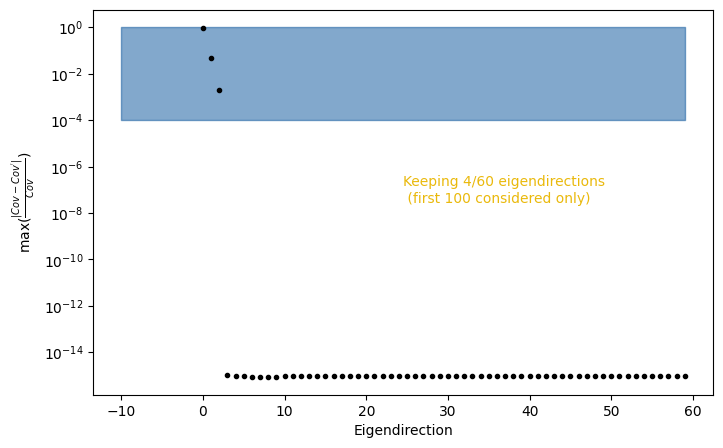

In [12]:
from sysvar import plot_cov_diff

fig, ax = plot_cov_diff(egd_custom)

This is consistent with what we mentioned earlier in the Information for Analysts: we retain the 4 dominant eigendirections, since there are only 4 uncorrelated correction weights.

What would happen if the errors were fully correlated ? 

In [13]:
custom_calibration_info = {
    'dependant_variable': 'custom_calibration_id',
     'central_values': [1.0115, 0.8532, 1.1194, 0.9663,
      ],
     'query_targets': ["-10211", "10211", "-20211", "20211"], # These have to be strings
     'uncertainties': {'fully_correlated': {'unc': [0.0528, 0.0926, 0.1766, 0.0942]}},
     'unit': '',
     'title': 'custom_calibration_weight',
     'name': 'custom_calibration'}


INFO : create_templates: 184 :  ########## Reco channel: channel1 ##########
INFO : create_templates: 215 :  Building TemplateND for bkg from 389 events
INFO : create_templates: 215 :  Building TemplateND for signal from 472 events
INFO : create_templates: 184 :  ########## Reco channel: channel2 ##########
INFO : create_templates: 215 :  Building TemplateND for bkg from 408 events
INFO : create_templates: 215 :  Building TemplateND for signal from 498 events
INFO : vary_templates: 148 :  ########## Reco channel: channel1 ##########
INFO : vary_templates: 162 :  Adding variations to bkg template
INFO : vary_templates: 162 :  Adding variations to signal template
INFO : vary_templates: 148 :  ########## Reco channel: channel2 ##########
INFO : vary_templates: 162 :  Adding variations to bkg template
INFO : vary_templates: 162 :  Adding variations to signal template
Building partial covariances: 100%|██████████| 58/58 [00:00<00:00, 13272.39it/s]
INFO : find_important_eigendimension_indice

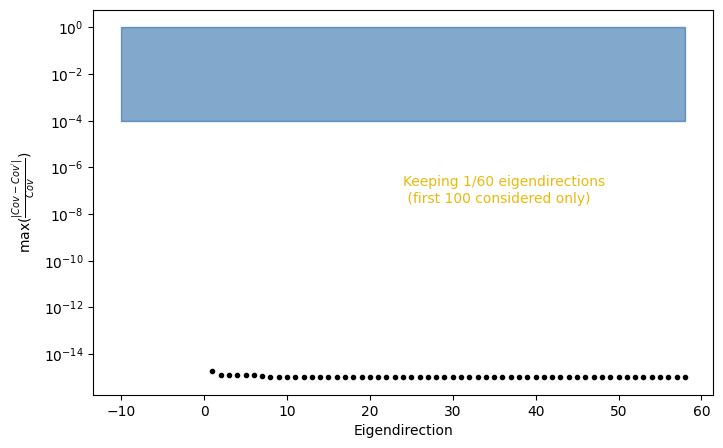

In [14]:
egd_custom_fully_corr = eigendecompose(
    df = toy_df,
    settings = settings,
    syst_effect = custom_calibration_info, # Notice that instead of a string here we pass a dictionary
)
fig, ax = plot_cov_diff(egd_custom_fully_corr)


Notice that now we retain only one dominant eigendirection, since the errors are fully correlated.

If these correction weights were obtained from a simultaneous fit and the covariance matrix between them is already available, you can pass this matrix directly to the `custom_calibration_info` dictionary. Now there is no need to specify the individual errors separately.

In [15]:
# Let's build a pseudo covariance matrix and save it in .npy format.

# diag_vals = np.array([x**2 for x in [0.0528, 0.0926, 0.1528, 0.0926]])
# n = len(diag_vals)

# cap_factor = 2 # off-diagonals will be in (-cap, cap) where cap = cap_factor * min(diag_i, diag_j)
# rng = np.random.default_rng(123)  # or np.random

# Sigma = np.diag(diag_vals.astype(float))

# for i in range(n):
#     for j in range(i+1, n):
#         cap = cap_factor * min(diag_vals[i], diag_vals[j])
#         val = rng.uniform(0, cap)
#         Sigma[i, j] = val
#         Sigma[j, i] = val

# np.save("cov_custom.npy", Sigma)

In [16]:
custom_calibration_info = {
    'dependant_variable': 'custom_calibration_id',
     'central_values': [1.0115, 0.8532, 1.1194, 0.9663,
      ],
     'query_targets': ["-10211", "10211", "-20211", "20211"],
     'unit': '',
     'title': 'custom_calibration_weight',
     'name': 'custom_calibration'}

Now we need to specify the covariance matrix path and then run the eigendecomposition

In [17]:
custom_calibration_info["cov_matrix_path"] = "cov_custom.npy"

INFO : load_covariance_matrix: 267 :  Loading covariance matrix from file specified in config: cov_custom.npy
/Users/agrimaggarwal/Documents/PhD/frameworks/sysvar/src/sysvar/variations.py:138: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  return np.random.multivariate_normal(zeros, covariance, Nvar)
INFO : create_templates: 184 :  ########## Reco channel: channel1 ##########
INFO : create_templates: 215 :  Building TemplateND for bkg from 389 events
INFO : create_templates: 215 :  Building TemplateND for signal from 472 events
INFO : create_templates: 184 :  ########## Reco channel: channel2 ##########
INFO : create_templates: 215 :  Building TemplateND for bkg from 408 events
INFO : create_templates: 215 :  Building TemplateND for signal from 498 events
INFO : vary_templates: 148 :  ########## Reco channel: channel1 ##########
INFO : vary_templates: 162 :  Adding variations to bkg template
INFO : vary_templates: 162 :  Adding variations to signal template
INFO :

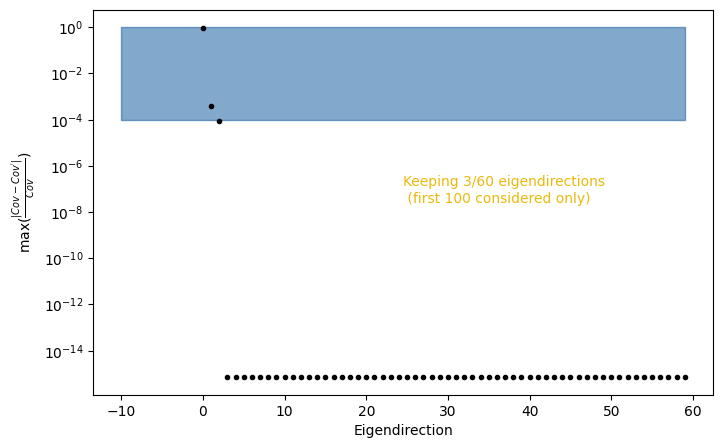

In [18]:

egd_custom_partial_corr = eigendecompose(
    df = toy_df,
    settings = settings,
    syst_effect = custom_calibration_info,
)
fig, ax = plot_cov_diff(egd_custom_partial_corr)

In this case, the number of relevant eigenvariations depends on the off-diagonal terms of the covariance matrix of the corrections. You can inspect the covariance matrix directly via `egd_custom_partial_corr.variator.cov_matrix` or use the Visualization API (see next section). 

Partial correlations are exactly the situations where SysVar’s full machinery provides the greatest advantage—beyond the book-keeping functionality, which remains relevant for the two cases we examined above.